### Project Setup & Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/telco_churn.csv")

In [4]:
print(df.shape)
print(df.dtypes)
print(df.head())

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45    

In [5]:
# TotalCharges is stored as a string
df["TotalCharges"].info

<bound method Series.info of 0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str>

In [6]:
# Number of null values in TotalCharges
print(df["TotalCharges"].isnull().sum())

0


In [7]:
# Change TotalCharges from string to integer
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# See if anything got nulled out
print(df["TotalCharges"].isnull().sum())

11


In [8]:
# Drop null 'TotalCharges' rows
df = df.dropna(subset=["TotalCharges"])

print(df.shape)

(7032, 21)


In [9]:
# Check the class imbalance
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(2))

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     0.73
Yes    0.27
Name: proportion, dtype: float64


### Feature Engineerimg & Encoding

In [10]:
# Drop customerID because it has no predictive value
df = df.drop(columns=["customerID"])

In [11]:
# Convert the target to binary
df["Churn"] = (df["Churn"] == "Yes").astype(int)


In [12]:
# See all unique values per non-numeric column
for col in df.select_dtypes(include="str").columns:
    print(f"{col}: {df[col].unique()}")

gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: 

In [13]:
# Map binary columns to 1/0
binary_cols = [
    "Partner", "Dependents", "PhoneService", 
    "PaperlessBilling", "MultipleLines", "OnlineSecurity", 
    "OnlineBackup", "DeviceProtection", "TechSupport", 
    "StreamingTV", "StreamingMovies"
]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 2, "No phone service": 0, "No internet service": 0})

# Handling multi-category columns
df = pd.get_dummies(df, columns=["gender", "InternetService", "Contract", "PaymentMethod"])

# Confirmation
print(df.shape)
print(df.select_dtypes(include="str").columns.tolist())

(7032, 28)
[]


### Train/Test Split & Model Training

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5625, 27)
(1407, 27)


In [15]:
# Train the model
from xgboost import XGBClassifier

model = XGBClassifier (
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=3,
    use_label_encoder=False,
    eval_matric="logloss",
    random_state=42
)

model.fit(X_train, y_train)
print("Training Complete")

/home/liphapang/Documents/Data Science/telco-customer-churn/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:26:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_matric", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Complete


In [16]:
print(df.select_dtypes(include="str").columns.tolist())

print(df.shape)

[]
(7032, 28)


              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407

ROC-AUC Score: 0.839


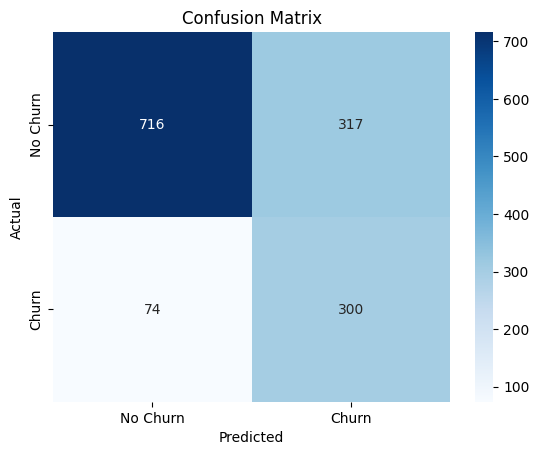

In [17]:
# Test set evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show();

### SHAP Explainability

/home/liphapang/Documents/Data Science/telco-customer-churn/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


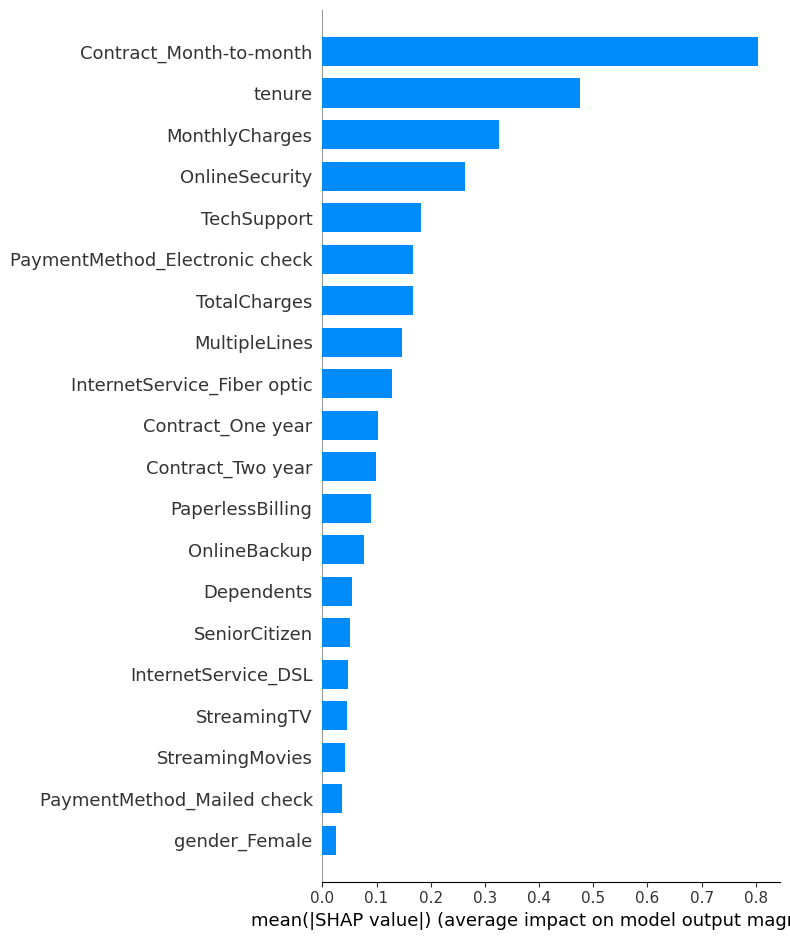

In [18]:
import shap

# Build explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

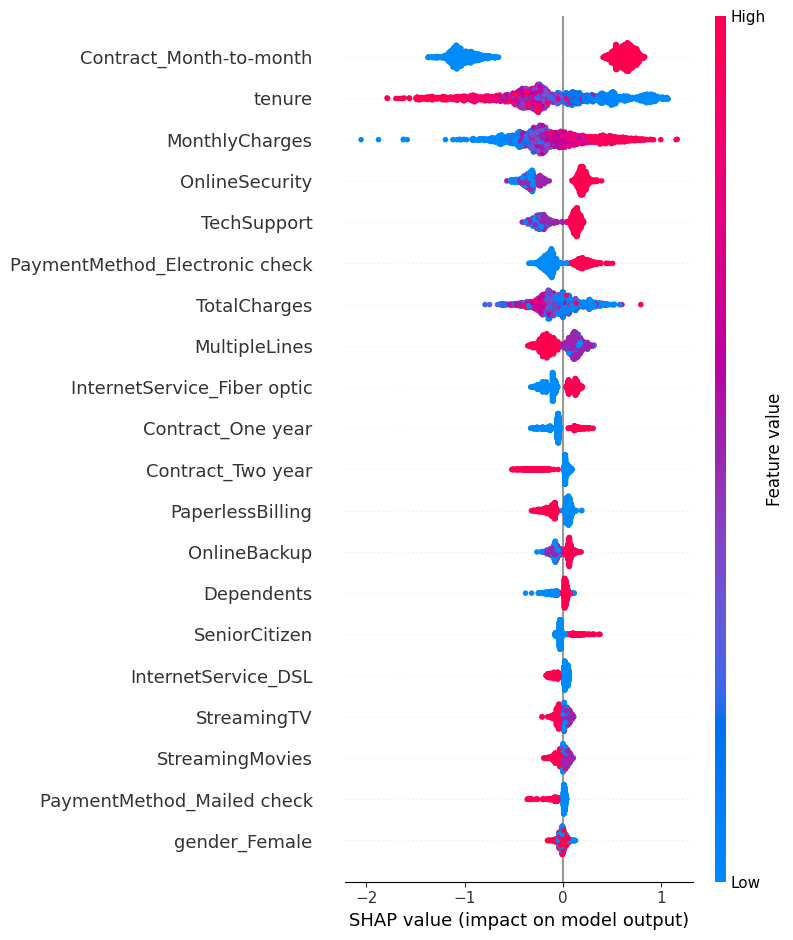

In [19]:
# Dot plot
shap.summary_plot(shap_values, X_test)

### Risk Scoring & AI Narrative

In [33]:
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
client = OpenAI(api_key = os.getenv("OPENAI_API_KEY"))

# Generate risk scores for the test set
risk_scores = (model.predict_proba(X_test)[:, 1] * 100).round(1)

In [34]:
# Build a results dataframe
results = X_test.copy().reset_index(drop=True)
results["ChurnRisk"] = risk_scores
results["ActualChurn"] = y_test.reset_index(drop=True)

In [35]:
# Focus on high-risk customers
high_risk = results[results["ChurnRisk"] > 60].copy()
print(f"High risk customers: {len(high_risk)}")
print(high_risk[["tenure", "MonthlyCharges", "Contract_Month-to-month", 
    "OnlineSecurity", "TechSupport", "ChurnRisk"]].head(10))

High risk customers: 498
    tenure  MonthlyCharges  Contract_Month-to-month  OnlineSecurity  \
1        7           78.55                     True               2   
5       60          105.90                     True               2   
8       14           87.25                     True               2   
10       4           70.20                     True               2   
12      14           78.10                     True               2   
15       2           90.40                     True               2   
16       3           75.00                     True               2   
17      22           79.35                     True               2   
21       4           64.40                     True               2   
22       1           49.30                     True               2   

    TechSupport  ChurnRisk  
1             2  84.900002  
5             2  73.199997  
8             2  82.400002  
10            2  82.400002  
12            2  82.300003  
15            2  90

In [38]:
def generate_churn_reason(row):
    prompt = f"""
    A telecom customer has been flagges as a high churn risk (score: {row['ChurnRisk']}/100).
    Their profile:
    - Tenure: {row['tenure']} months
    - Monthly charges: ${row['MonthlyCharges']}
    - Month-to-month contract: {'Yes' if row["Contract_Month-to-month"] == 1 else 'No'}
    - Online Security: {'Yes' if row['OnlineSecurity'] ==1 else 'No'}
    - Tech support: {'Yes' if row['TechSupport'] == 1 else 'No'}

    Write ONE plain-English sentence explaining why this customer is at risk.
    Be specific. Do not start with 'This customer'.
    """

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=60
    )
    return response.choices[0].message.content.strip()

In [39]:
high_risk = high_risk.head(5).copy()
high_risk["AIReason"] = high_risk.apply(generate_churn_reason, axis=1)

print(high_risk[["ChurnRisk", "AIReason"]])

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [40]:
def generate_churn_reason(row):
    reasons = []

    if row["Contract_Month-to-month"] == 1:
        reasons.append("on a month-to-month contract with no long-term commitment")
    if row["tenure"] < 12:
        reasons.append(f"only been a customer for {row['tenure']} months")
    if row["MonthlyCharges"] > 70:
        reasons.append(f"paying a high monthly charge of ${row['MonthlyCharges']}")
    if row["OnlineSecurity"] == 0:
        reasons.append("no online security add-on")
    if row["TechSupport"] == 0:
        reasons.append("no tech support subscription")

    if reasons:
        return "At risk due to: " + ", ".join(reasons) + "."
    return "Multiple moderate risk factors detected."

In [41]:
import joblib

joblib.dump(model, "model/churn_model.pkl")
joblib.dump(X_test.columns.tolist(), "model/feature_columns.pkl")

print("Model saved successfully")

Model saved successfully
